# **🚀 AI Resume Screening System**



## Step 0: Libraries Install Karein



In [1]:
!pip install -q sentence-transformers spacy gradio datasets PyPDF2 groq scikit-learn pandas matplotlib seaborn
!python -m spacy download en_core_web_sm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 70.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import re
import os
import io
import string
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer, util
import spacy

print("✅ Core libraries imported. Spacy aur sentence-transformers model neeche load honge.")

✅ Core libraries imported. Spacy aur sentence-transformers model neeche load honge.


## Step 1: Sample Job Description aur Resumes


In [3]:
job_description = """
We are looking for a Data Scientist with strong experience in Python, Machine Learning,
Data Analysis, SQL, and Deep Learning. Experience with TensorFlow, Pandas, NumPy, and
Scikit-learn is required. Good communication and problem solving skills are a plus.
"""

resumes = {
    "Ali_Khan.pdf": """
    Ali Khan - Data Scientist with 3 years experience in Python, Machine Learning,
    Deep Learning, TensorFlow, Pandas and SQL. Built predictive models and worked on
    data analysis projects at a fintech startup. Contact: ali.khan99@gmail.com, +92-300-1234567.
    """,
    "Sara_Ahmed.pdf": """
    Sara Ahmed - Web Developer skilled in HTML, CSS, JavaScript, React and Node.js.
    Built responsive websites and worked with REST APIs for e-commerce clients.
    Email: sara.ahmed@example.com, Phone: 021-111-2233. 4 years of experience.
    """,
    "Bilal_Raza.pdf": """
    Bilal Raza - Software Engineer with experience in Java, Spring Boot, SQL databases
    and some exposure to Python and Machine Learning basics. bilal.raza@example.com
    """,
    "Hina_Malik.pdf": """
    Hina Malik - Data Analyst proficient in SQL, Excel, Power BI, Python, Pandas and
    basic Machine Learning. Strong communication and problem solving skills.
    hina.malik@example.com, +92-333-9876543, 2 years of experience.
    """,
    "Usman_Tariq.pdf": """
    Usman Tariq - HR Specialist with recruitment, employee relations, payroll and
    onboarding experience. Skilled in MS Office and communication. usman.t@example.com
    """,
}

print(f"📄 Job description ready. Total sample resumes: {len(resumes)}")

📄 Job description ready. Total sample resumes: 5


## Step 2: Semantic Matching — Sentence-Transformers (BERT-based)



In [4]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

def clean_text(text):
    text = re.sub(r"\s+", " ", text).strip()
    return text

cleaned_job = clean_text(job_description)
cleaned_resumes = {name: clean_text(txt) for name, txt in resumes.items()}

job_embedding = embedding_model.encode(cleaned_job, convert_to_tensor=True)
resume_names = list(cleaned_resumes.keys())
resume_embeddings = embedding_model.encode(list(cleaned_resumes.values()), convert_to_tensor=True)

semantic_scores = util.cos_sim(job_embedding, resume_embeddings).flatten().tolist()

semantic_results = pd.DataFrame({
    "Resume": resume_names,
    "Semantic Match Score (%)": [round(s * 100, 2) for s in semantic_scores]
}).sort_values(by="Semantic Match Score (%)", ascending=False).reset_index(drop=True)

semantic_results.insert(0, "Rank", range(1, len(semantic_results) + 1))
semantic_results

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

,Rank,Resume,Semantic Match Score (%)
0,1,Hina_Malik.pdf,63.11
1,2,Ali_Khan.pdf,59.08
2,3,Bilal_Raza.pdf,51.91
3,4,Sara_Ahmed.pdf,24.95
4,5,Usman_Tariq.pdf,23.78


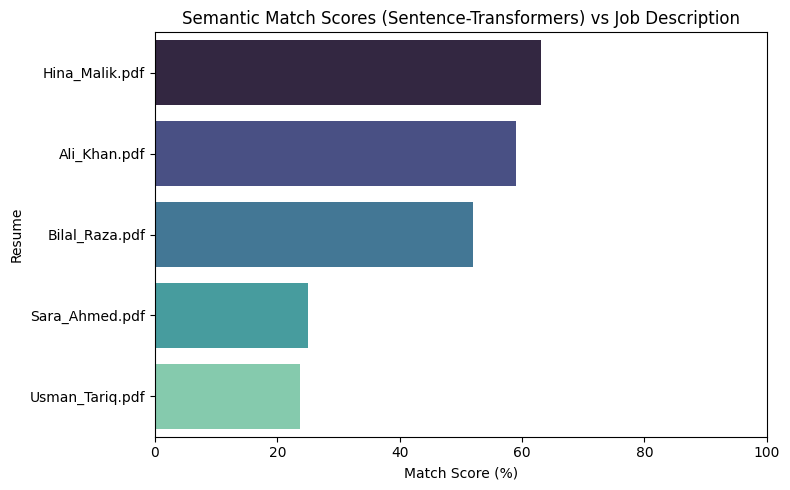

In [5]:
plt.figure(figsize=(8, 5))
sns.barplot(data=semantic_results, x="Semantic Match Score (%)", y="Resume", hue="Resume",
            palette="mako", legend=False)
plt.title("Semantic Match Scores (Sentence-Transformers) vs Job Description")
plt.xlabel("Match Score (%)")
plt.ylabel("Resume")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

## Step 3: Automatic Info Extraction — spaCy NER + Regex

Ab har resume se automatically nikalenge:
- 👤 **Name** (spaCy Named Entity Recognition se)
- 📧 **Email**
- 📱 **Phone Number**
- ⏳ **Years of Experience** (agar mention ho)

In [6]:
nlp = spacy.load("en_core_web_sm")

def extract_email(text):
    m = re.search(r"[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+", text)
    return m.group(0) if m else "Not found"

def extract_phone(text):
    m = re.search(r"(?:\+?\d{1,3}[-.\s]?)?\(?\d{3,4}\)?[-.\s]?\d{3,4}[-.\s]?\d{3,4}", text)
    return m.group(0).strip() if m else "Not found"

def extract_experience_years(text):
    m = re.search(r"(\d+)\+?\s*(?:years|yrs)\.?\s*(?:of)?\s*experience", text, re.IGNORECASE)
    return f"{m.group(1)} years" if m else "Not mentioned"

def extract_name(text):
    doc = nlp(text)
    people = [ent.text for ent in doc.ents if ent.label_ == "PERSON"]
    return people[0] if people else "Not detected"

extracted_info = []
for name, txt in resumes.items():
    extracted_info.append({
        "Resume File": name,
        "Detected Name": extract_name(txt),
        "Email": extract_email(txt),
        "Phone": extract_phone(txt),
        "Experience": extract_experience_years(txt),
    })

info_df = pd.DataFrame(extracted_info)
info_df

,Resume File,Detected Name,Email,Phone,Experience
0,Ali_Khan.pdf,Ali Khan - Data,ali.khan99@gmail.com,+92-300-1234567,3 years
1,Sara_Ahmed.pdf,Sara Ahmed - Web Developer,sara.ahmed@example.com,021-111-2233,4 years
2,Bilal_Raza.pdf,Bilal Raza - Software,bilal.raza@example.com,Not found,Not mentioned
3,Hina_Malik.pdf,Hina Malik - Data,hina.malik@example.com,+92-333-9876543,2 years
4,Usman_Tariq.pdf,Usman Tariq - HR Specialist,usman.t@example.com,Not found,Not mentioned


## Step 4: Real-World Dataset Se Classifier Train Karein

Pichli notebook mein sirf **16 synthetic examples** se classifier train hua tha. Ab hum ek **real 2,484-resume dataset** use karenge — yehi mashhoor Kaggle **"Resume Dataset"** hai (24 job categories: HR, IT, Designer, Teacher, Sales, Finance, waghera), Hugging Face par bina kisi login/auth ke available hai.

In [7]:
from datasets import load_dataset

# NOTE: this repo contains BOTH a clean CSV/Parquet table AND 2400+ individual PDF files.
# Without pinning the revision, load_dataset can pick the wrong (PDF-folder) config,
# which tries to download every PDF individually and gives the wrong columns.
# revision="refs/convert/parquet" forces it to use HF's auto-converted clean table
# (columns: ID, Resume_str, Resume_html, Category) -- fast, no PDFs downloaded.
try:
    raw_dataset = load_dataset("opensporks/resumes", split="train", revision="refs/convert/parquet")
    resume_df = raw_dataset.to_pandas()[["Resume_str", "Category"]].rename(columns={"Resume_str": "text"})
except Exception as e:
    print(f"⚠️ load_dataset approach failed ({e}), trying direct pandas fallback...")
    import pandas as pd
    resume_df = pd.read_parquet("hf://datasets/opensporks/resumes/default/train-00000-of-00001.parquet")
    resume_df = resume_df[["Resume_str", "Category"]].rename(columns={"Resume_str": "text"})

print("Total resumes:", len(resume_df))
print("Total categories:", resume_df["Category"].nunique())
resume_df["Category"].value_counts()

default/train/0000.parquet: reconstructing file:   0%|          |  0.00B / 20.0MB            

default/train/0000.parquet: downloading bytes:           |  0.00B            

Generating train split: 0 examples [00:00, ? examples/s]

Total resumes: 2484
Total categories: 24


,count
Category,
INFORMATION-TECHNOLOGY,120
BUSINESS-DEVELOPMENT,120
ADVOCATE,118
CHEF,118
ENGINEERING,118
ACCOUNTANT,118
FINANCE,118
FITNESS,117
AVIATION,117


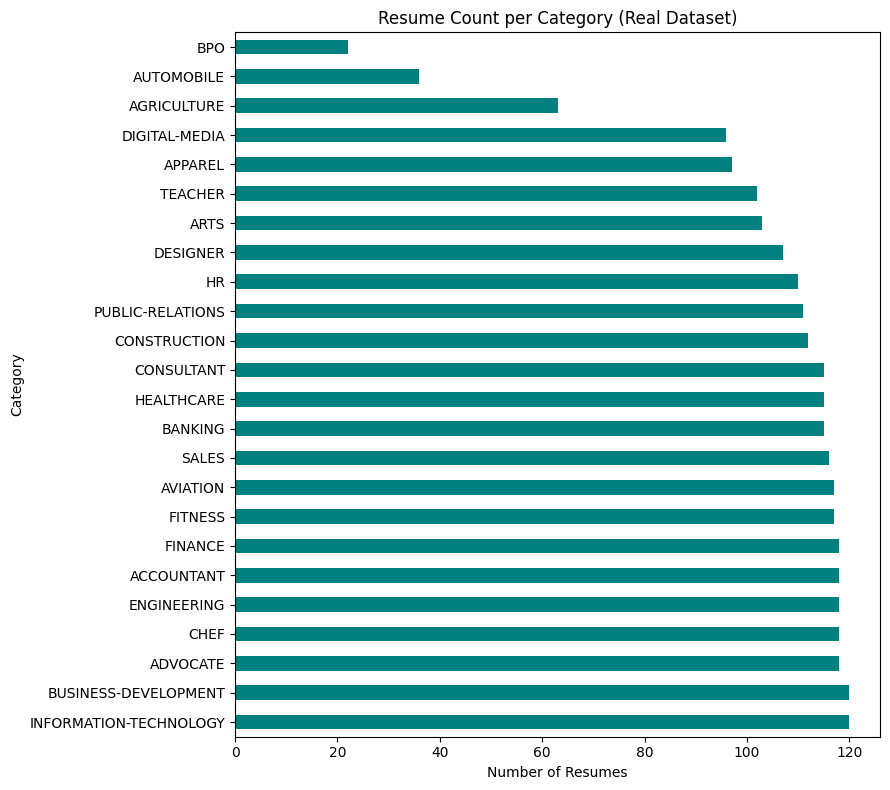

In [8]:
plt.figure(figsize=(9, 8))
resume_df["Category"].value_counts().plot(kind="barh", color="teal")
plt.title("Resume Count per Category (Real Dataset)")
plt.xlabel("Number of Resumes")
plt.tight_layout()
plt.show()

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    resume_df["text"], resume_df["Category"], test_size=0.2, random_state=42, stratify=resume_df["Category"]
)

real_vectorizer = TfidfVectorizer(stop_words="english", max_features=8000)
X_train_vec = real_vectorizer.fit_transform(X_train)
X_test_vec = real_vectorizer.transform(X_test)

real_classifier = LogisticRegression(max_iter=1000)
real_classifier.fit(X_train_vec, y_train)

preds = real_classifier.predict(X_test_vec)
print("✅ Test Accuracy:", round(accuracy_score(y_test, preds) * 100, 2), "%")
print()
print(classification_report(y_test, preds, zero_division=0))

✅ Test Accuracy: 64.79 %

                        precision    recall  f1-score   support

            ACCOUNTANT       0.65      0.83      0.73        24
              ADVOCATE       0.35      0.54      0.43        24
           AGRICULTURE       1.00      0.38      0.56        13
               APPAREL       0.67      0.21      0.32        19
                  ARTS       0.46      0.29      0.35        21
            AUTOMOBILE       0.00      0.00      0.00         7
              AVIATION       0.85      0.71      0.77        24
               BANKING       0.83      0.65      0.73        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.46      0.79      0.58        24
                  CHEF       0.81      0.71      0.76        24
          CONSTRUCTION       0.82      0.82      0.82        22
            CONSULTANT       0.50      0.17      0.26        23
              DESIGNER       0.84      0.76      0.80        21
         DIGI

In [10]:
def predict_resume_category(text):
    vec = real_vectorizer.transform([text])
    return real_classifier.predict(vec)[0]

for name, txt in resumes.items():
    print(f"{name} -> Predicted Category: {predict_resume_category(txt)}")

Ali_Khan.pdf -> Predicted Category: CONSULTANT
Sara_Ahmed.pdf -> Predicted Category: CONSULTANT
Bilal_Raza.pdf -> Predicted Category: ENGINEERING
Hina_Malik.pdf -> Predicted Category: ENGINEERING
Usman_Tariq.pdf -> Predicted Category: HR


## Step 5:
- 📄 CV upload (PDF/TXT) ya paste
- 💼 Job Description upload (PDF/TXT) ya paste
- 🧠 Semantic match score
- 🏷️ Extracted Name/Email/Phone/Experience
- 📊 Predicted job category (real-dataset-trained model)
- 🤖 Full AI analysis

In [15]:
import gradio as gr
from groq import Groq
import groq as groq_module

def read_uploaded_file(file_path):
    if not file_path:
        return ""
    ext = os.path.splitext(file_path)[1].lower()
    if ext == ".pdf":
        import PyPDF2
        reader = PyPDF2.PdfReader(file_path)
        text = ""
        for page in reader.pages:
            t = page.extract_text()
            if t:
                text += t + " "
        return text
    elif ext == ".txt":
        with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
            return f.read()
    return ""

CAREER_SYSTEM_PROMPT = """You are an AI career assistant.
The user will upload either their CV/resume or a job description.
Your tasks are:
1. Read and understand the uploaded text.
2. Summarize the main points (skills, experience, requirements).
3. Compare the CV against the job description.
4. Explain clearly whether the user is eligible for the job or not.
5. If not fully eligible, list the missing skills or requirements.
6. Give practical advice on how the user can become eligible (courses, certifications, experience, projects).
7. Always provide realistic, supportive, and actionable feedback in simple English.
Output format:
- 📄 CV Summary
- 💼 Job Summary
- ✅ Matching Skills/Experience
- ⚠️ Missing Skills/Requirements
- 🎯 Eligibility Result (Eligible / Partially Eligible / Not Eligible)
- 🚀 Suggestions to Improve Eligibility
"""

def full_analysis(cv_file, cv_text_box, jd_file, jd_text_box, groq_api_key, progress=gr.Progress()):
    progress(0.1, desc="Reading documents...")
    cv_content = read_uploaded_file(cv_file) or cv_text_box or ""
    jd_content = read_uploaded_file(jd_file) or jd_text_box or ""

    if not cv_content.strip() or not jd_content.strip():
        return "⚠️ **Please provide both a CV and a Job Description** (upload a file or paste text in either tab)."

    output_parts = []

    progress(0.3, desc="Computing semantic match...")
    job_emb = embedding_model.encode(clean_text(jd_content), convert_to_tensor=True)
    cv_emb = embedding_model.encode(clean_text(cv_content), convert_to_tensor=True)
    sem_score = round(float(util.cos_sim(job_emb, cv_emb)[0][0]) * 100, 2)
    output_parts.append(f"## 🧠 Semantic Match Score: **{sem_score}%**")

    progress(0.5, desc="Extracting candidate info...")
    output_parts.append(
        f"## 🏷️ Extracted Info\n"
        f"| Field | Value |\n|---|---|\n"
        f"| 👤 Name | {extract_name(cv_content)} |\n"
        f"| 📧 Email | {extract_email(cv_content)} |\n"
        f"| 📱 Phone | {extract_phone(cv_content)} |\n"
        f"| ⏳ Experience | {extract_experience_years(cv_content)} |"
    )

    progress(0.65, desc="Predicting job category...")
    predicted_cat = predict_resume_category(cv_content)
    output_parts.append(f"## 📊 Predicted Job Category: **{predicted_cat}**")

    if groq_api_key and groq_api_key.strip():
        progress(0.8, desc="Running AI career analysis...")
        try:
            client = Groq(api_key=groq_api_key.strip())
            response = client.chat.completions.create(
                model="openai/gpt-oss-120b",
                max_tokens=1500,
                messages=[
                    {"role": "system", "content": CAREER_SYSTEM_PROMPT},
                    {"role": "user", "content": f"CV:\n---\n{cv_content.strip()}\n---\n\nJob Description:\n---\n{jd_content.strip()}\n---"}
                ]
            )
            output_parts.append("## 🤖 Full AI Career Analysis\n" + response.choices[0].message.content)
        except groq_module.AuthenticationError:
            output_parts.append("## 🤖 Full AI Career Analysis\n❌ Invalid Groq API key.")
        except groq_module.APIError as e:
            output_parts.append(f"## 🤖 Full AI Career Analysis\n❌ API error: {e}")
    else:
        output_parts.append("## 🤖 Full AI Career Analysis\n_(No Groq API key given — this section skipped. Free key: console.groq.com/keys)_")

    progress(1.0, desc="Done!")
    return "\n\n---\n\n".join(output_parts)

def clear_fields():
    return None, "", None, "", "", "_Results will appear here after you click Analyze._"

# ---------------- 🌌 Futuristic Neon Theme ----------------
custom_css = """
.gradio-container {
    background: radial-gradient(circle at top left, #1b0033, #05000f 55%, #000000 100%) !important;
    max-width: 1200px !important;
    margin: auto !important;
}
#header {text-align: center; padding: 34px 0 18px 0;}
#header h1 {
    font-size: 2.7em; font-weight: 800; margin-bottom: 6px;
    background: linear-gradient(90deg, #00d4ff, #a855f7, #ec4899);
    -webkit-background-clip: text; -webkit-text-fill-color: transparent; background-clip: text;
    filter: drop-shadow(0 0 18px rgba(168, 85, 247, 0.55));
}
#header p {color: #c4b5fd; font-size: 1.1em;}

#input-card, #output-card {
    background: rgba(255,255,255,0.04);
    backdrop-filter: blur(14px);
    border: 1px solid rgba(168, 85, 247, 0.35);
    border-radius: 22px;
    padding: 22px;
    box-shadow: 0 0 25px rgba(139, 92, 246, 0.25), 0 0 60px rgba(236, 72, 153, 0.08);
    transition: box-shadow 0.4s ease;
}
#input-card:hover, #output-card:hover {
    box-shadow: 0 0 35px rgba(139, 92, 246, 0.4), 0 0 80px rgba(236, 72, 153, 0.15);
}

.section-label {
    font-weight: 700; font-size: 1.05em; margin: 6px 0 4px 0;
    background: linear-gradient(90deg, #60a5fa, #c084fc);
    -webkit-background-clip: text; -webkit-text-fill-color: transparent;
}

#analyze-btn {
    background: linear-gradient(90deg, #3b82f6, #a855f7, #ec4899) !important;
    background-size: 200% auto !important;
    color: white !important; border: none !important; border-radius: 14px !important;
    font-weight: 700 !important; font-size: 1.05em !important; height: 48px !important;
    box-shadow: 0 0 20px rgba(168, 85, 247, 0.5); transition: 0.3s ease;
}
#analyze-btn:hover {
    background-position: right center !important;
    box-shadow: 0 0 35px rgba(236, 72, 153, 0.75);
    transform: translateY(-2px);
}
#clear-btn {
    border-radius: 14px !important; border: 1px solid rgba(236, 72, 153, 0.4) !important;
    color: #f0abfc !important; background: rgba(255,255,255,0.03) !important;
}

#result-box {min-height: 320px;}
#result-box, #result-box * { color: #e8e6ff !important; }

#brand-footer {
    text-align: center; margin-top: 22px; padding-bottom: 10px;
    font-size: 0.95em; color: #a5b4fc; letter-spacing: 0.4px;
}
#brand-footer span {
    background: linear-gradient(90deg, #00d4ff, #a855f7, #ec4899);
    -webkit-background-clip: text; -webkit-text-fill-color: transparent; font-weight: 700;
    filter: drop-shadow(0 0 6px rgba(236, 72, 153, 0.5));
}

@media (max-width: 768px) {
    #header h1 { font-size: 1.8em; }
    #input-card, #output-card { padding: 14px; border-radius: 16px; }
}
"""

theme = gr.themes.Base(
    primary_hue="purple", secondary_hue="pink", neutral_hue="slate",
    font=[gr.themes.GoogleFont("Poppins"), "sans-serif"],
).set(
    body_background_fill="#05000f",
    block_background_fill="rgba(255,255,255,0.03)",
    block_border_color="rgba(168,85,247,0.3)",
    input_background_fill="rgba(255,255,255,0.06)",
    button_primary_background_fill="linear-gradient(90deg, #3b82f6, #a855f7, #ec4899)",
    button_primary_text_color="white",
)

with gr.Blocks(theme=theme, css=custom_css, title="AI Resume Screening Assistant") as demo:
    gr.HTML("""
    <div id="header">
        <h1>⚡ AI Resume Screening Assistant</h1>
        <p>🧠 Semantic Matching &nbsp;•&nbsp; 🏷️ Auto-Extracted Info &nbsp;•&nbsp; 📊 ML Prediction &nbsp;•&nbsp; 🤖 AI Career Analysis</p>
    </div>
    """)

    with gr.Row():
        with gr.Column(scale=1, elem_id="input-card"):
            gr.HTML('<div class="section-label">📄 Candidate CV</div>')
            with gr.Tabs():
                with gr.Tab("📁 Upload File"):
                    cv_file = gr.File(label="PDF or TXT", file_types=[".pdf", ".txt"])
                with gr.Tab("✍️ Paste Text"):
                    cv_text_box = gr.Textbox(label="CV Text", lines=8, placeholder="Paste CV/resume text here...")

            gr.HTML('<div class="section-label">💼 Job Description</div>')
            with gr.Tabs():
                with gr.Tab("📁 Upload File"):
                    jd_file = gr.File(label="PDF or TXT", file_types=[".pdf", ".txt"])
                with gr.Tab("✍️ Paste Text"):
                    jd_text_box = gr.Textbox(label="Job Description Text", lines=8, placeholder="Paste job description here...")

            groq_api_key = gr.Textbox(label="🔑 Groq API Key (optional, free)", type="password",
                                        placeholder="Leave blank to skip the AI summary")

            with gr.Row():
                clear_btn = gr.Button("🗑️ Clear", elem_id="clear-btn")
                analyze_btn = gr.Button("🚀 Analyze", elem_id="analyze-btn")

        with gr.Column(scale=1, elem_id="output-card"):
            gr.HTML('<div class="section-label">📊 Results</div>')
            result_output = gr.Markdown(elem_id="result-box", value="_Results will appear here after you click Analyze._")

    gr.HTML('<div id="brand-footer">⚡ Powered by <span>Haseeb Ahmed</span></div>')

    analyze_btn.click(fn=full_analysis, inputs=[cv_file, cv_text_box, jd_file, jd_text_box, groq_api_key], outputs=result_output)
    clear_btn.click(fn=clear_fields, inputs=[], outputs=[cv_file, cv_text_box, jd_file, jd_text_box, groq_api_key, result_output])

demo.launch(share=True, debug=False)

/tmp/ipykernel_1063/423821827.py:181: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=theme, css=custom_css, title="AI Resume Screening Assistant") as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cc0ee25aea126a3974.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
